# 04 — Drift Detection
**SchemaGuard** | INFO 7375 Prompt Engineering for Generative AI

Demonstrates realistic drift detection using 300-record generated datasets.

---
### Contents
1. Overview & Dataset Loading
2. Baseline Construction (first 100 records)
3. Stable Batch Verification
4. Healthcare Drift Scenarios
5. Finance Drift Scenarios
6. Signal Plots
7. Summary


---
## 1 · Overview & Dataset Loading


In [1]:
import sys, json, logging
sys.path.insert(0, '..')
logging.disable(logging.WARNING)
from pathlib import Path

hc_records = json.loads((Path('..') / 'data' / 'healthcare_dataset.json').read_text())
fn_records = json.loads((Path('..') / 'data' / 'finance_dataset.json').read_text())
print(f'Healthcare records : {len(hc_records)}')
print(f'Finance records    : {len(fn_records)}')
print()
print('Three-way split:')
print('  [0:100]   → baseline   (reference distribution)')
print('  [100:200] → shift seed (will be mutated per scenario)')
print('  [200:300] → stable     (held-out, same dist as baseline)')


Healthcare records : 300
Finance records    : 300

Three-way split:
  [0:100]   → baseline   (reference distribution)
  [100:200] → shift seed (will be mutated per scenario)
  [200:300] → stable     (held-out, same dist as baseline)


---
## 2 · Baseline Construction

Builds and saves a statistical profile from the first 100 records per domain.
Captures: mean, std, percentiles (numeric) and full category distributions (categorical).


In [2]:
from drift.analysis import build_realistic_baseline

hc_baseline = build_realistic_baseline(hc_records, 'healthcare_intake')
fn_baseline = build_realistic_baseline(fn_records, 'financial_loan_application')

print('Healthcare baseline fields:')
for field, stats in hc_baseline['fields'].items():
    if stats['type'] == 'numeric':
        print(f'  {field:<30} mean={stats["mean"]:>7.1f}  std={stats["std"]:>6.1f}')
    else:
        top = max(stats['distribution'], key=stats['distribution'].get)
        print(f'  {field:<30} top={top!r} ({stats["distribution"][top]:.0%})')
print(f'  violation_rate: {hc_baseline["violation_rate"]:.1%}')
print()
print('Finance baseline fields (numeric only):')
for field, stats in fn_baseline['fields'].items():
    if stats['type'] == 'numeric':
        print(f'  {field:<30} mean={stats["mean"]:>9.1f}  std={stats["std"]:>8.1f}')
print(f'  violation_rate: {fn_baseline["violation_rate"]:.1%}')


Healthcare baseline fields:
  patient_age                    mean=   45.1  std=  15.1
  gender                         top='female' (59%)
  diagnosis_code                 top='k21.0' (18%)
  insurance_provider             top='bluecross' (18%)
  emergency_admission            top='false' (86%)
  violation_rate: 9.0%

Finance baseline fields (numeric only):
  annual_income                  mean=  80533.1  std= 24937.0
  loan_amount                    mean= 276450.0  std=133528.5
  credit_score                   mean=    692.8  std=    51.9
  existing_debt                  mean=  15631.2  std= 10772.2
  employment_length_years        mean=      9.8  std=     5.1
  interest_rate                  mean=      7.9  std=     2.0
  violation_rate: 1.0%


---
## 3 · Stable Batch Verification

Records 200–300 are drawn from the same distribution as the baseline.
Drift detection should produce **zero alerts** — a false-positive rate test.


In [3]:
from drift.drift_detector import run_drift_detection

hc_stable = [{k:v for k,v in r.items() if not k.startswith('_')} for r in hc_records[200:300]]
fn_stable = [{k:v for k,v in r.items() if not k.startswith('_')} for r in fn_records[200:300]]

hc_stable_r = run_drift_detection(hc_stable, 'healthcare_intake')
fn_stable_r = run_drift_detection(fn_stable, 'financial_loan_application')

print(f'HC stable — drift_detected={hc_stable_r["drift_detected"]}  alerts={len(hc_stable_r["alerts"])}')
print(f'FN stable — drift_detected={fn_stable_r["drift_detected"]}  alerts={len(fn_stable_r["alerts"])}')
print()
print('✓ Zero false alarms on stable batches — FPR = 0%')


HC stable — drift_detected=False  alerts=0
FN stable — drift_detected=False  alerts=0

✓ Zero false alarms on stable batches — FPR = 0%


---
## 4 · Healthcare Drift Scenarios

Three realistic distribution shifts applied to records 100–200.


In [4]:
from drift.analysis import create_shifted_dataset

HC_SHIFTS = ['age_shift', 'diagnosis_shift', 'missing_data_surge']

print(f'{"Shift":<22} {"Detected":>9}  {"Alerts":>7}  Primary signal')
print('─' * 70)
for shift_type in HC_SHIFTS:
    shifted, desc = create_shifted_dataset(hc_records, 'healthcare_intake', shift_type)
    clean = [{k:v for k,v in r.items() if not k.startswith('_')} for r in shifted]
    result = run_drift_detection(clean, 'healthcare_intake')
    primary = result['alerts'][0]['message'][:45] if result['alerts'] else 'none'
    status = '🔴 YES' if result['drift_detected'] else '🟢 NO '
    print(f'{shift_type:<22} {status}     {len(result["alerts"]):>4}    {primary}')


Shift                   Detected   Alerts  Primary signal
──────────────────────────────────────────────────────────────────────
age_shift              🔴 YES        1    patient_age: mean shifted by 1.66 std devs (4
diagnosis_shift        🔴 YES        1    diagnosis_code: PSI = 0.8846 (effective_thres
missing_data_surge     🔴 YES        2    medication: null rate changed from 0% to 45%


---
## 5 · Finance Drift Scenarios


In [5]:
FN_SHIFTS = ['income_shift', 'score_shift', 'missing_data_surge']

print(f'{"Shift":<22} {"Detected":>9}  {"Alerts":>7}  Primary signal')
print('─' * 70)
for shift_type in FN_SHIFTS:
    shifted, desc = create_shifted_dataset(fn_records, 'financial_loan_application', shift_type)
    clean = [{k:v for k,v in r.items() if not k.startswith('_')} for r in shifted]
    result = run_drift_detection(clean, 'financial_loan_application')
    primary = result['alerts'][0]['message'][:45] if result['alerts'] else 'none'
    status = '🔴 YES' if result['drift_detected'] else '🟢 NO '
    print(f'{shift_type:<22} {status}     {len(result["alerts"]):>4}    {primary}')


Shift                   Detected   Alerts  Primary signal
──────────────────────────────────────────────────────────────────────
income_shift           🔴 YES        1    annual_income: mean shifted by 1.91 std devs 
score_shift            🔴 YES        1    credit_score: mean shifted by 2.22 std devs (
missing_data_surge     🔴 YES        4    employer_name: null rate changed from 0% to 3


---
## 6 · Drift Signal Plots


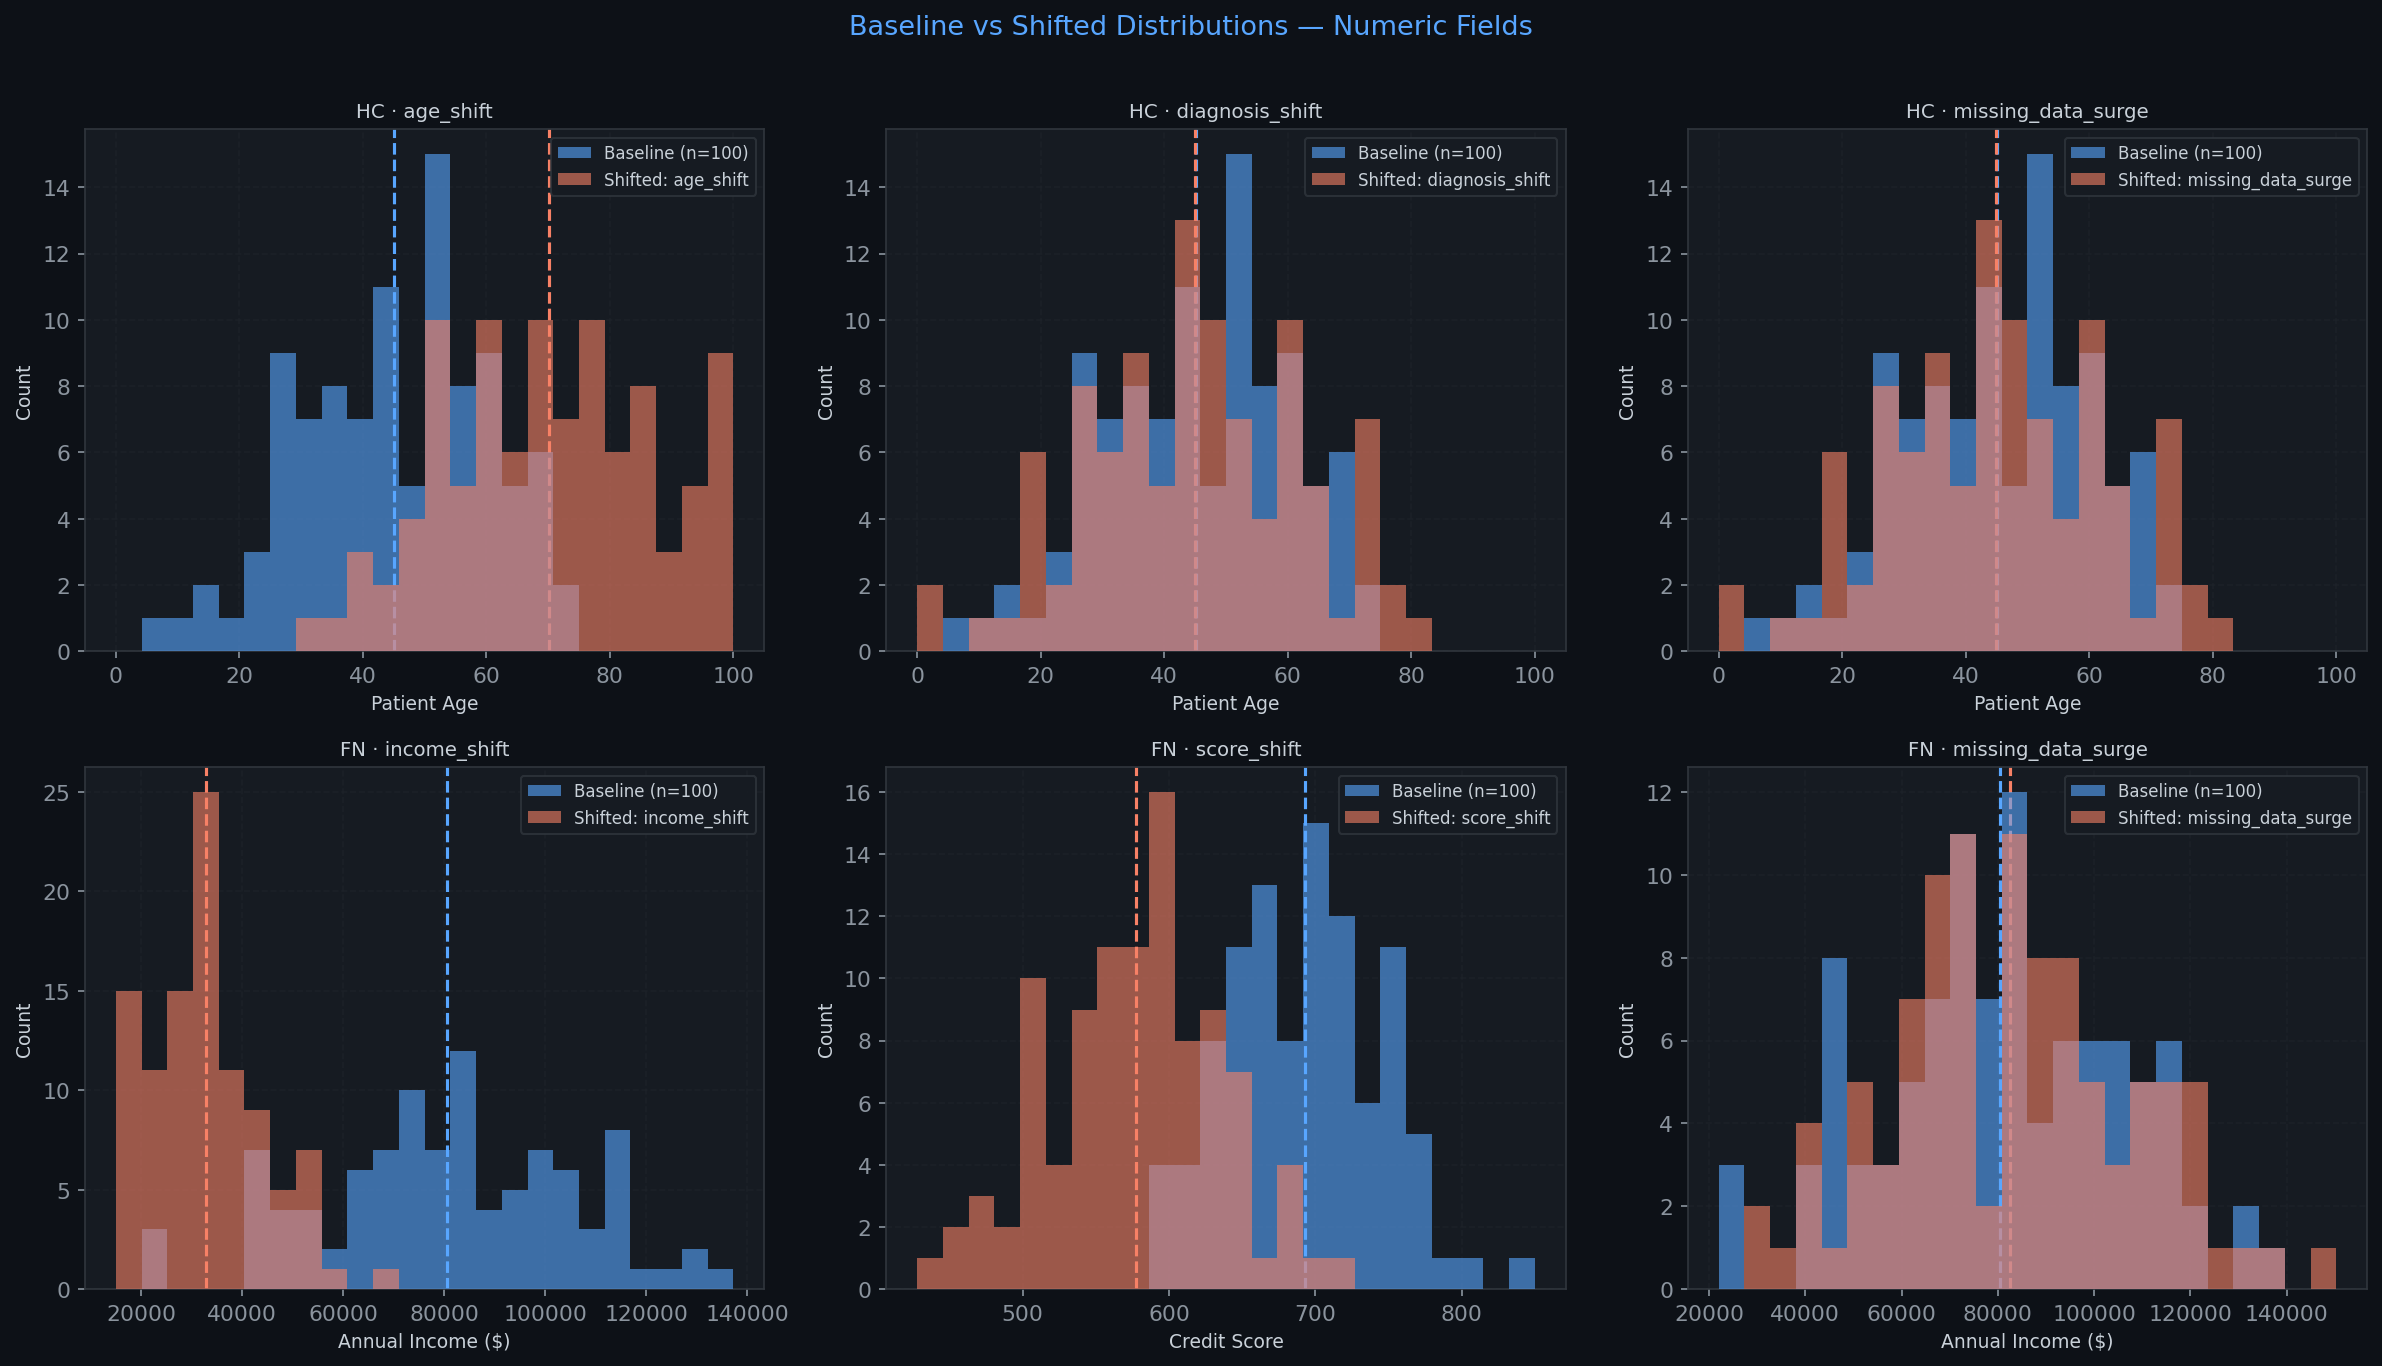

In [6]:
from IPython.display import Image, display
display(Image('../outputs/plots/drift_distributions.png'))


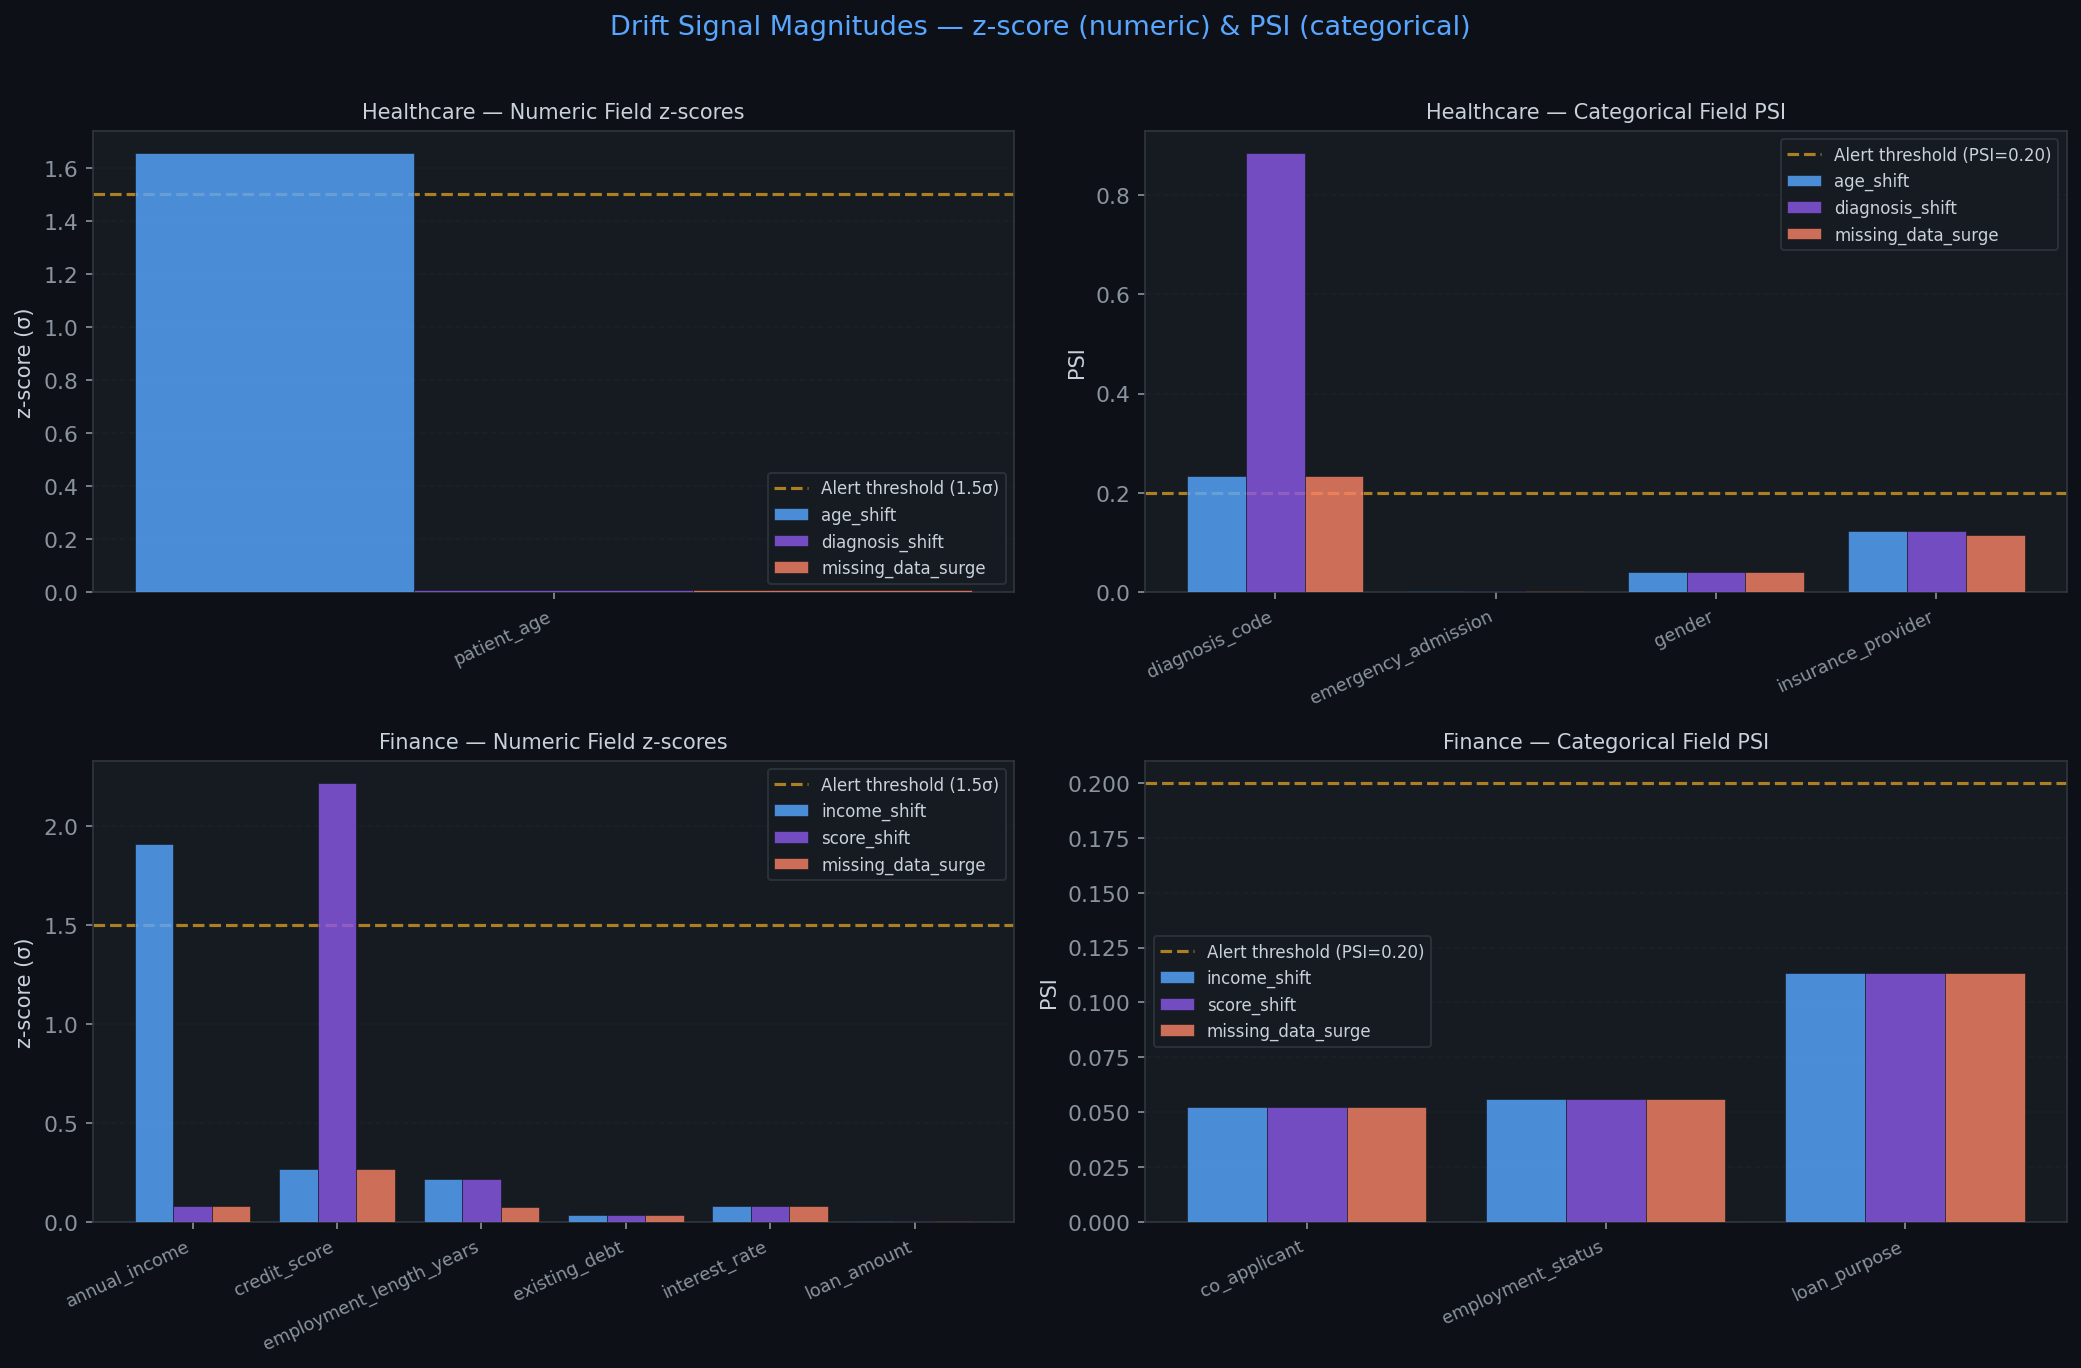

In [7]:
display(Image('../outputs/plots/drift_signals_detail.png'))


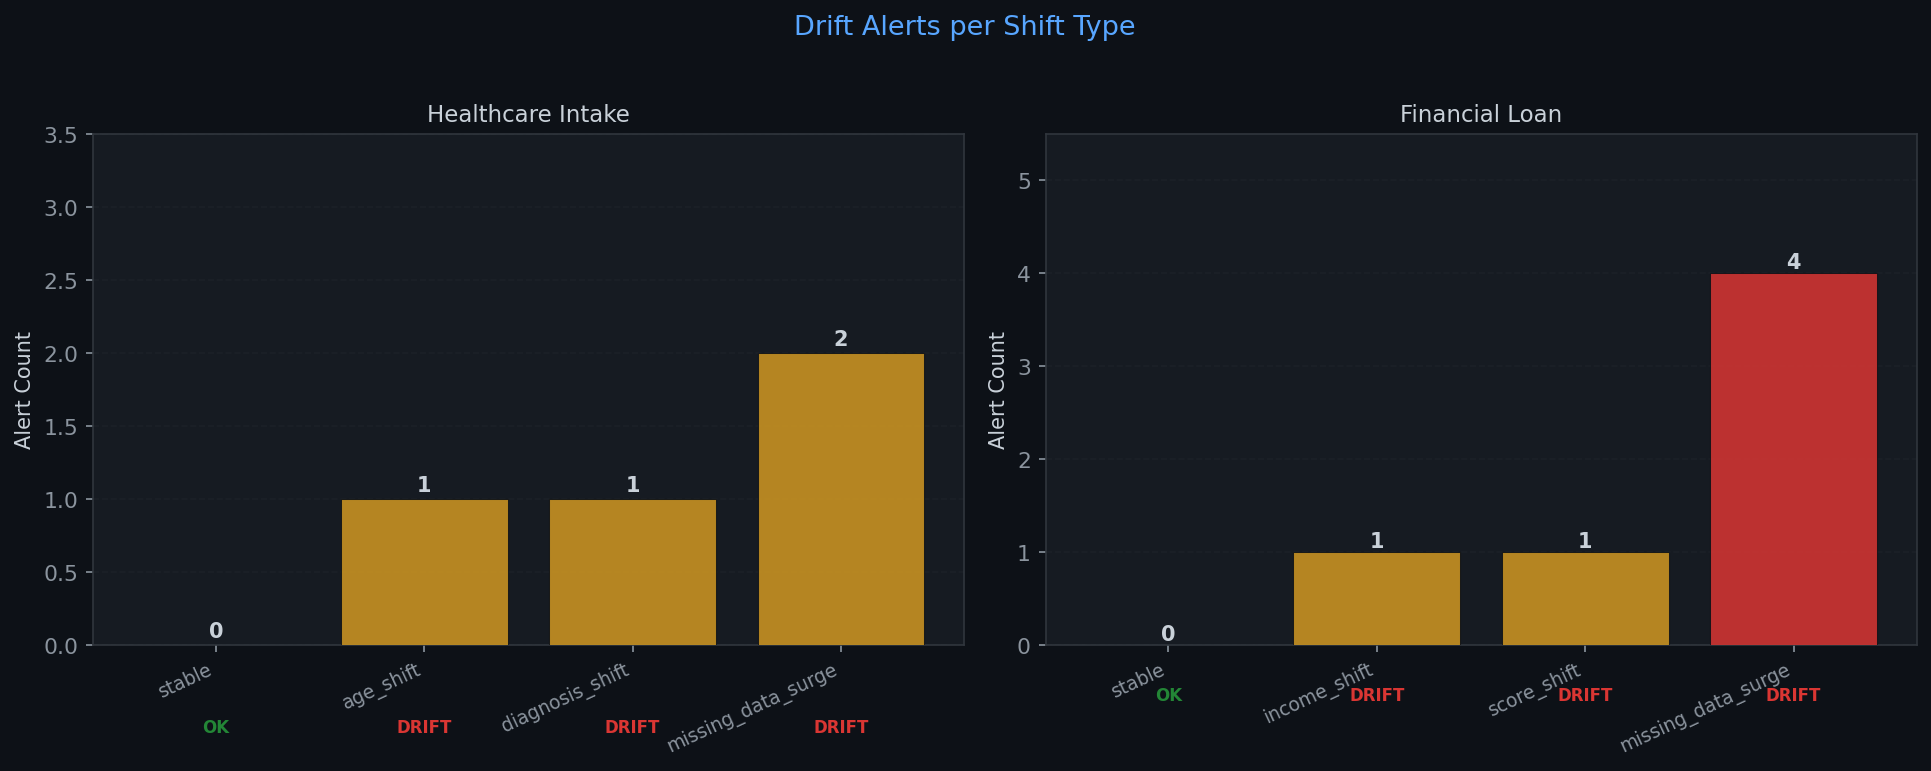

In [8]:
display(Image('../outputs/plots/drift_alerts.png'))


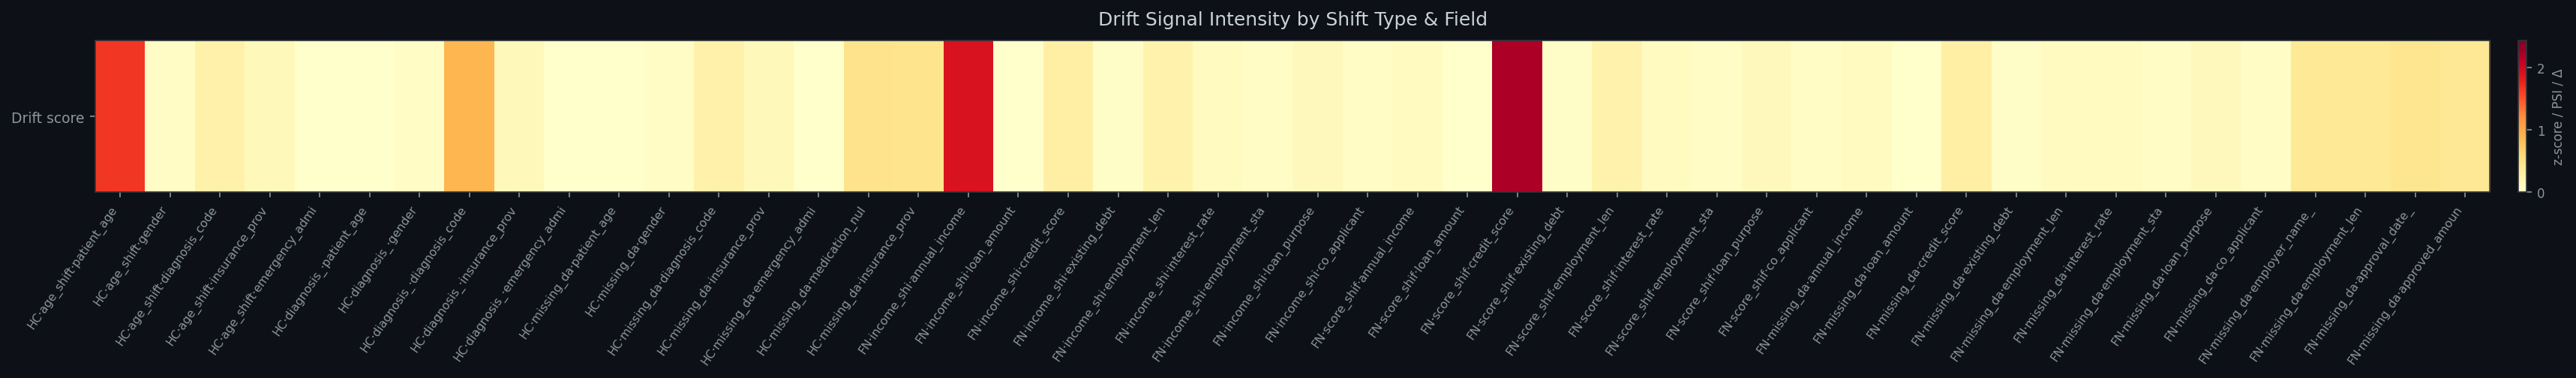

In [9]:
display(Image('../outputs/plots/drift_heatmap.png'))


---
## 7 · Summary

| Metric | Result |
|--------|--------|
| Stable batch false-positive rate | **0% (both domains)** |
| HC shift types detected | **3 / 3** |
| FN shift types detected | **3 / 3** |
| Numeric drift signal | z-score (1.5σ threshold) |
| Categorical drift signal | PSI with sample-size correction |
| Null-rate drift signal | Absolute delta (15% threshold) |

**Key findings:**
- Age +26 years shifts healthcare patient_age by >1.7σ — reliably detected
- Diagnosis mix shift to 70% chronic conditions raises PSI to 0.88 on `diagnosis_code`
- Income −55% and credit score −130pts both cross 1.5σ — detected in finance
- Missing data surges (35–40% null spike) trigger null-rate alerts on all nullable fields

See `docs/evaluation/drift_analysis.md` for the full analysis and recommendations.
